In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("victorianomh/idealista-barcelona-raw-scraped-data")

print("Path to dataset files:", path)

In [196]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report

import optuna
import optuna.visualization as vis
import time

import scipy.stats as st

from sklearn.datasets import  fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, make_scorer, mean_absolute_percentage_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from scipy.stats import ttest_ind
import pickle
from sklearn.pipeline import Pipeline
import joblib

## EDA

In [197]:
df = pd.read_csv(r'..\data\raw\raw_data.csv')

In [198]:
df2 = pd.read_csv(r'..\data\raw\clean_data.csv')

In [199]:
df3 = pd.read_csv(r'..\data\raw\structured_dataw_description.csv')

In [200]:
df.shape

(10389, 7)

In [201]:
df2.shape

(10106, 24)

In [202]:
df3.shape

(14359, 29)

In [203]:
df.head()

,id,title,neighborhood,price,info_features,features,description
0,103375204,Flat / apartment for sale in calle de Sant Pau...,"El Raval, Barcelona","530,000","['80 m²', '2 bed.', '3rd floor exterior with l...","[['80 m² built', '2 bedrooms', '1 bathroom', '...","Beautiful renovated apartment of 80 m2, 2 bedr..."
1,94000904,Flat / apartment for sale in Hospìtal,"El Raval, Barcelona","165,000","['58 m²', '2 bed.', '3rd floor exterior withou...","[['58 m² built, 49 m² floor area', '2 bedrooms...",This two-bedroom flat is located in an unbeata...
2,104382041,Flat / apartment for sale in El Raval,"Ciutat Vella, Barcelona","430,000","['155 m²', '3 bed.', '1st floor exterior with ...","[['155 m² built, 89 m² floor area', '3 bedroom...",Spacious and modern apartment on one side of L...
3,97791792,Flat / apartment for sale in rambla del Raval,"El Raval, Barcelona","279,999","['89 m²', '2 bed.', '3rd floor exterior withou...","[['89 m² built, 80 m² floor area', '2 bedrooms...","MERC SANT ANTONI - RAMBLA RAVAL, two apartment..."
4,104397583,Flat / apartment for sale in calle de les Carr...,"El Raval, Barcelona","230,000","['70 m²', '2 bed.', '1st floor exterior with l...","[['70 m² built', '2 bedrooms', '2 bathrooms', ...",Immotecnics exclusively presents this incredib...


In [204]:
df2.head()

,id,property_type,address,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,...,balcony,second_hand,needs_renovating,parking,swimming pool,garden,air_conditioning,heating,log_price,city-neighborhood
0,103375204,Flat / apartment,"calle de Sant Pau, 25",El Raval,Barcelona,530000.0,80,2,1,3,...,True,True,False,False,False,False,True,True,13.180634,Barcelona - El Raval
1,94000904,Flat / apartment,Hospìtal,El Raval,Barcelona,165000.0,58,2,1,3,...,True,True,False,False,False,False,False,False,12.013707,Barcelona - El Raval
2,104382041,Flat / apartment,El Raval,Ciutat Vella,Barcelona,430000.0,155,3,2,1,...,True,True,False,False,False,False,True,True,12.971543,Barcelona - Ciutat Vella
3,97791792,Flat / apartment,rambla del Raval,El Raval,Barcelona,279999.0,89,2,2,3,...,True,True,False,False,False,False,True,True,12.542545,Barcelona - El Raval
4,104397583,Flat / apartment,calle de les Carretes,El Raval,Barcelona,230000.0,70,2,2,1,...,True,True,False,False,False,False,True,False,12.345839,Barcelona - El Raval


In [205]:
df2.columns

Index(['id', 'property_type', 'address', 'neighborhood', 'city', 'price',
       'sq_m_built', 'n_bedrooms', 'bathrooms', 'floor', 'year_built',
       'exterior', 'lift', 'terrace', 'balcony', 'second_hand',
       'needs_renovating', 'parking', 'swimming pool', 'garden',
       'air_conditioning ', 'heating', 'log_price', 'city-neighborhood'],
      dtype='object')

In [206]:
df3.columns

Index(['id', 'property_type', 'adress', 'neighborhood', 'city', 'price',
       'sq_m_built', 'sq_m_floor_area', 'n_bedrooms', 'bathrooms', 'floor_y',
       'year_built', 'exterior_x', 'lift_x', 'terrace', 'balcony',
       'second hand', 'needs renovating', 'parking', 'swimming pool', 'garden',
       'air conditioning', 'heating', 'central_heating', 'heating_type',
       'consumption_in_mkw/m2_year', 'emissions_in_kgco2/m2_year',
       'orientation', 'description'],
      dtype='object')

In [207]:
df3.head()

,id,property_type,adress,neighborhood,city,price,sq_m_built,sq_m_floor_area,n_bedrooms,bathrooms,...,swimming pool,garden,air conditioning,heating,central_heating,heating_type,consumption_in_mkw/m2_year,emissions_in_kgco2/m2_year,orientation,description
0,103375204,Flat / apartment,"calle de Sant Pau, 25",El Raval,Barcelona,530000.0,80,NaN,2,1,...,False,False,True,True,central,NaN,91.0,17.0,NaN,"Beautiful renovated apartment of 80 m2, 2 bedr..."
1,94000904,Flat / apartment,Hospìtal,El Raval,Barcelona,165000.0,58,49.0,2,1,...,False,False,False,False,no,NaN,311.0,65.0,south,This two-bedroom flat is located in an unbeata...
2,104382041,Flat / apartment,El Raval,Ciutat Vella,Barcelona,430000.0,155,89.0,3,2,...,False,False,True,True,central,NaN,NaN,NaN,NaN,Spacious and modern apartment on one side of L...
3,97791792,Flat / apartment,rambla del Raval,El Raval,Barcelona,279999.0,89,80.0,2,2,...,False,False,True,True,individual,electric,15.0,71.0,north,"MERC SANT ANTONI - RAMBLA RAVAL, two apartment..."
4,104397583,Flat / apartment,calle de les Carretes,El Raval,Barcelona,230000.0,70,NaN,2,2,...,False,False,True,False,no,NaN,90.0,190.0,north,Immotecnics exclusively presents this incredib...


> After analyze the three files. The structured have all the info necessary.

In [208]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14359 entries, 0 to 14358
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          14359 non-null  int64  
 1   property_type               14359 non-null  object 
 2   adress                      14359 non-null  object 
 3   neighborhood                14359 non-null  object 
 4   city                        13860 non-null  object 
 5   price                       14359 non-null  float64
 6   sq_m_built                  14359 non-null  int64  
 7   sq_m_floor_area             7458 non-null   float64
 8   n_bedrooms                  14359 non-null  int64  
 9   bathrooms                   14359 non-null  int64  
 10  floor_y                     14359 non-null  int64  
 11  year_built                  9255 non-null   float64
 12  exterior_x                  14359 non-null  bool   
 13  lift_x                      143

In [209]:
df3['property_type'].value_counts()

property_type
Flat / apartment       11818
Penthouse                932
Duplex                   709
Detached house           293
Terraced house           248
Studio flat              213
House                     70
Semi-detached house       69
Estate                     4
Village house              2
Tower                      1
Name: count, dtype: int64

## Fixing columns names

In [210]:
df3 = df3.rename(columns={'adress':'address'})

In [211]:
df3 = df3.rename(columns={'floor_y':'floor', 'exterior_x':'exterior', 'lift_x':'lift'})

In [212]:
df3 = df3.rename(columns={'second hand':'second_hand', 'needs renovating':'needs_renovating', 'air conditioning':'air_conditioning', 'swimming pool':'swimming_pool'})

## Seeking for duplicated values

In [213]:
df3.duplicated().sum()

4250

In [214]:
duplicated_id = df3.loc[df3['id'].duplicated(),'id']

In [215]:
duplicated_id

18       104142563
19       104142563
20       104142563
21       104142563
22       104142563
           ...    
14256    104224966
14257    104224966
14258    104224966
14259    104224966
14260    104224966
Name: id, Length: 4250, dtype: int64

> Dropping duplicates

In [216]:
df3 = df3.drop_duplicates(subset=['id'], keep='first')

In [217]:
df3.shape

(10109, 29)

## Cheking for null values

In [218]:
df3.isna().sum()

id                               0
property_type                    0
address                          0
neighborhood                     0
city                           274
price                            0
sq_m_built                       0
sq_m_floor_area               4691
n_bedrooms                       0
bathrooms                        0
floor                            0
year_built                    3359
exterior                         0
lift                             0
terrace                          0
balcony                          0
second_hand                      0
needs_renovating                 0
parking                          0
swimming_pool                    0
garden                           0
air_conditioning                 0
heating                          0
central_heating               3972
heating_type                  6806
consumption_in_mkw/m2_year    4586
emissions_in_kgco2/m2_year    4863
orientation                   5497
description         

In [219]:
df3['city'].value_counts()

city
Barcelona                   7884
Hospitalet de Llobregat      814
Badalona                     771
Santa Coloma de Gramenet     320
Sant Adriá de Besós           46
Name: count, dtype: int64

In [220]:
na_city = df3.loc[df3['city'].isna()]

## Fill in NA values on City column using the neighborhood

In [221]:
df3.loc[(df3['city'].isna()) & (df3['neighborhood'] == 'Santa Coloma de Gramenet'),'city'] = 'Santa Coloma de Gramenet'

In [222]:
df3.loc[(df3['city'].isna()) & (df3['neighborhood'] == 'Badalona'),'city'] = 'Badalona'

In [223]:
df3.loc[(df3['city'].isna()) & (df3['neighborhood'] == 'Sant Adriá de Besós'),'city'] = 'Sant Adriá de Besós	'

> Eliminated all NA from city columns

In [224]:
df3.isna().sum()

id                               0
property_type                    0
address                          0
neighborhood                     0
city                             0
price                            0
sq_m_built                       0
sq_m_floor_area               4691
n_bedrooms                       0
bathrooms                        0
floor                            0
year_built                    3359
exterior                         0
lift                             0
terrace                          0
balcony                          0
second_hand                      0
needs_renovating                 0
parking                          0
swimming_pool                    0
garden                           0
air_conditioning                 0
heating                          0
central_heating               3972
heating_type                  6806
consumption_in_mkw/m2_year    4586
emissions_in_kgco2/m2_year    4863
orientation                   5497
description         

> Replacing typo on city column

In [225]:
df3['city'].value_counts()

city
Barcelona                   7884
Badalona                     836
Hospitalet de Llobregat      814
Santa Coloma de Gramenet     501
Sant Adriá de Besós           46
Sant Adriá de Besós\t         28
Name: count, dtype: int64

In [226]:
df3['city'] = df3['city'].replace('Sant Adriá de Besós\t', 'Sant Adriá de Besós')

> For floor area, consuption and emission and orientention will drop the columns. 

In [227]:
df3 = df3.drop("sq_m_floor_area", axis=1)

In [228]:
df3 = df3.drop("consumption_in_mkw/m2_year", axis=1)

In [229]:
df3 = df3.drop("emissions_in_kgco2/m2_year", axis=1)

In [230]:
df3 = df3.drop("orientation", axis=1)

> Ill drop the heating columns with NA values, because I already have a column with this info. 

In [231]:
df3 = df3.drop("central_heating", axis=1)

In [232]:
df3 = df3.drop("heating_type", axis=1)

> Drop id column. Will not be necessary for the analyses. 

In [233]:
df3 = df3.drop("id", axis=1)

> Drop address column. Its relevant to the analysis, but is too many unique values to be considerer. 

In [234]:
df3 = df3.drop("address", axis=1)

In [235]:
df3.isna().sum()

property_type          0
neighborhood           0
city                   0
price                  0
sq_m_built             0
n_bedrooms             0
bathrooms              0
floor                  0
year_built          3359
exterior               0
lift                   0
terrace                0
balcony                0
second_hand            0
needs_renovating       0
parking                0
swimming_pool          0
garden                 0
air_conditioning       0
heating                0
description            0
dtype: int64

> For NA in year, ill fill in with the mean of the year by the neighborhood.    

In [236]:
df3['year_built'] = df3.groupby('neighborhood')['year_built'].transform(lambda x: x.fillna(x.mean()))

In [237]:
df3.isna().sum()

property_type       0
neighborhood        0
city                0
price               0
sq_m_built          0
n_bedrooms          0
bathrooms           0
floor               0
year_built          3
exterior            0
lift                0
terrace             0
balcony             0
second_hand         0
needs_renovating    0
parking             0
swimming_pool       0
garden              0
air_conditioning    0
heating             0
description         0
dtype: int64

In [238]:
df3.loc[df3['year_built'].isna()]

,property_type,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built,exterior,...,terrace,balcony,second_hand,needs_renovating,parking,swimming_pool,garden,air_conditioning,heating,description
5217,Penthouse,Manresa,Badalona,465000.0,80,3,2,3,NaN,True,...,True,True,False,False,False,False,False,False,True,INVESTMENT OPPORTUNITY IN FRONT OF MONTGAT NEX...
11949,Flat / apartment,Baró de Viver,Barcelona,379000.0,126,3,2,2,NaN,True,...,False,False,True,False,False,False,False,False,False,"Floor 2nd, flat total surface area 126 m², usa..."
14286,Duplex,Manresa,Badalona,525000.0,113,3,3,2,NaN,True,...,True,True,False,False,False,False,False,False,True,INVESTMENT OPPORTUNITY IN FRONT OF MONTGAT NEX...


> The remain ill drop

In [239]:
df3 = df3.dropna(subset=['year_built'])

In [240]:
df3.isna().sum()

property_type       0
neighborhood        0
city                0
price               0
sq_m_built          0
n_bedrooms          0
bathrooms           0
floor               0
year_built          0
exterior            0
lift                0
terrace             0
balcony             0
second_hand         0
needs_renovating    0
parking             0
swimming_pool       0
garden              0
air_conditioning    0
heating             0
description         0
dtype: int64

In [241]:
df3.dtypes

property_type        object
neighborhood         object
city                 object
price               float64
sq_m_built            int64
n_bedrooms            int64
bathrooms             int64
floor                 int64
year_built          float64
exterior               bool
lift                   bool
terrace                bool
balcony                bool
second_hand            bool
needs_renovating       bool
parking                bool
swimming_pool          bool
garden                 bool
air_conditioning       bool
heating                bool
description          object
dtype: object

In [242]:
df3.head()

,property_type,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built,exterior,...,terrace,balcony,second_hand,needs_renovating,parking,swimming_pool,garden,air_conditioning,heating,description
0,Flat / apartment,El Raval,Barcelona,530000.0,80,2,1,3,1912.0,True,...,True,True,True,False,False,False,False,True,True,"Beautiful renovated apartment of 80 m2, 2 bedr..."
1,Flat / apartment,El Raval,Barcelona,165000.0,58,2,1,3,1850.0,True,...,False,True,True,False,False,False,False,False,False,This two-bedroom flat is located in an unbeata...
2,Flat / apartment,Ciutat Vella,Barcelona,430000.0,155,3,2,1,2003.0,True,...,True,True,True,False,False,False,False,True,True,Spacious and modern apartment on one side of L...
3,Flat / apartment,El Raval,Barcelona,279999.0,89,2,2,3,1920.0,True,...,False,True,True,False,False,False,False,True,True,"MERC SANT ANTONI - RAMBLA RAVAL, two apartment..."
4,Flat / apartment,El Raval,Barcelona,230000.0,70,2,2,1,1900.0,True,...,False,True,True,False,False,False,False,True,False,Immotecnics exclusively presents this incredib...


In [243]:
df_num = df3[['price','sq_m_built','n_bedrooms','bathrooms','floor','year_built']]

In [244]:
df_num.describe()

,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built
count,1.010600e+04,10106.000000,10106.000000,10106.000000,10106.000000,10106.000000
mean,5.304608e+05,111.770236,2.907877,1.676628,2.430338,1957.331185
std,7.093306e+05,98.416633,1.254984,0.957959,2.511162,36.233410
min,2.500000e+04,19.000000,0.000000,0.000000,-2.000000,1710.000000
25%,1.950000e+05,65.000000,2.000000,1.000000,1.000000,1941.091954
50%,3.350000e+05,85.000000,3.000000,1.000000,2.000000,1967.000000
75%,5.800000e+05,120.000000,3.000000,2.000000,4.000000,1975.153846
max,2.100000e+07,1800.000000,17.000000,10.000000,25.000000,2026.000000


## Checking for outliers

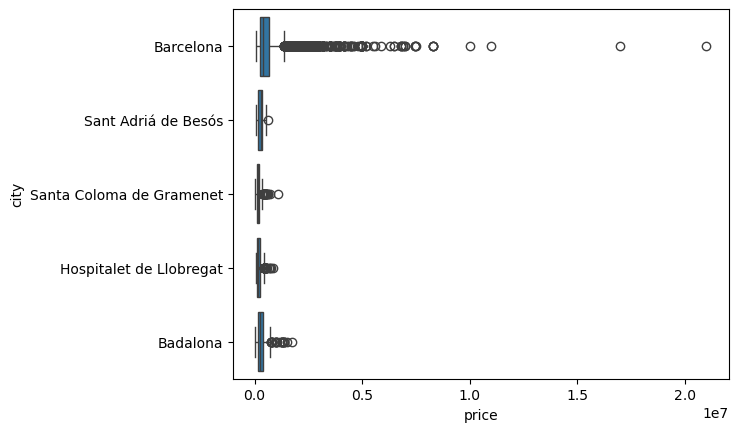

In [245]:
sns.boxplot(y = 'city', x = 'price', data = df3)
plt.show()

> Removing the outliers

In [246]:
Q1 = df3['price'].quantile(0.25)
Q3 = df3['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 6 * IQR

df3 = df3[(df3['price'] >= lower_bound) & (df3['price'] <= upper_bound)]

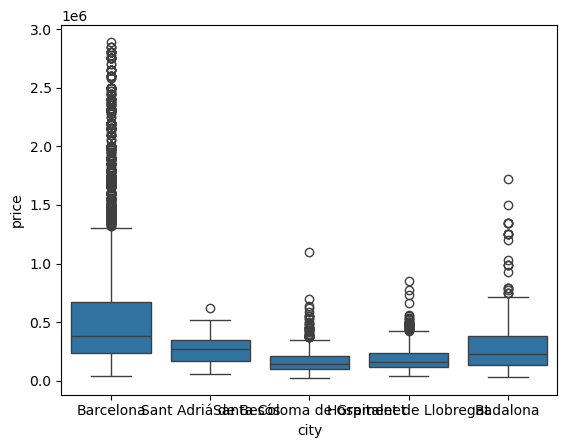

In [247]:
sns.boxplot(x = 'city', y = 'price', data = df3)
plt.show()

## Check numerical values for distribution

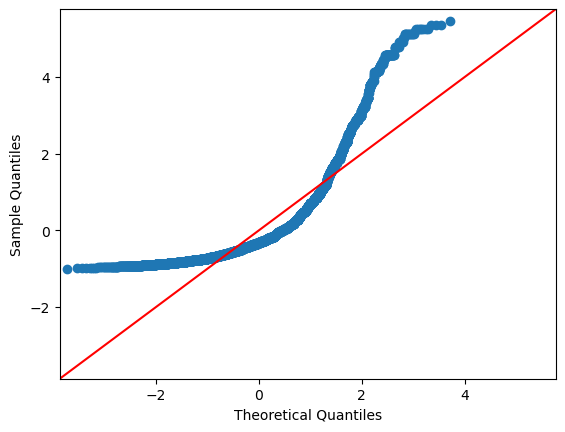

In [248]:
import statsmodels.api as sm
sm.qqplot(df3['price'].values, fit=True, line='45')
plt.show()

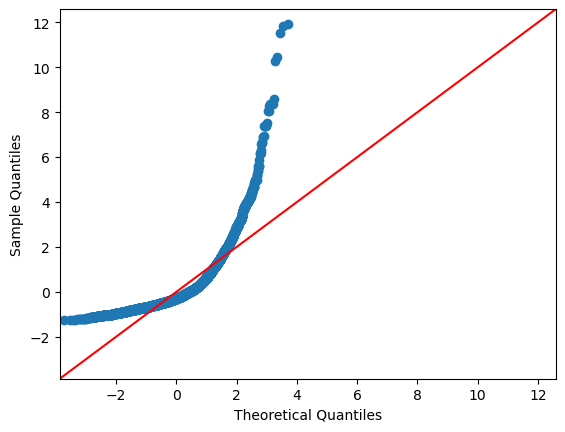

In [249]:
sm.qqplot(df3['sq_m_built'].values, fit=True, line='45')
plt.show()

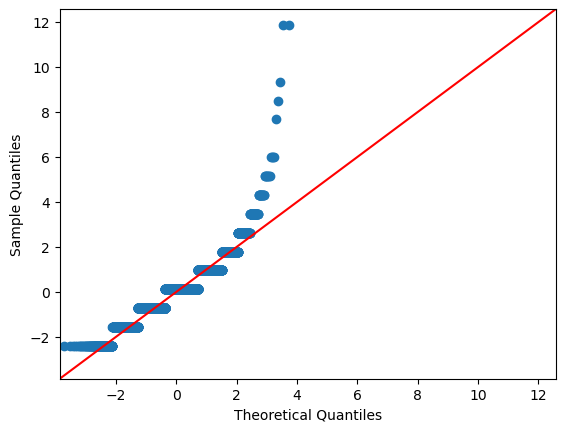

In [250]:
sm.qqplot(df3['n_bedrooms'].values, fit=True, line='45')
plt.show()

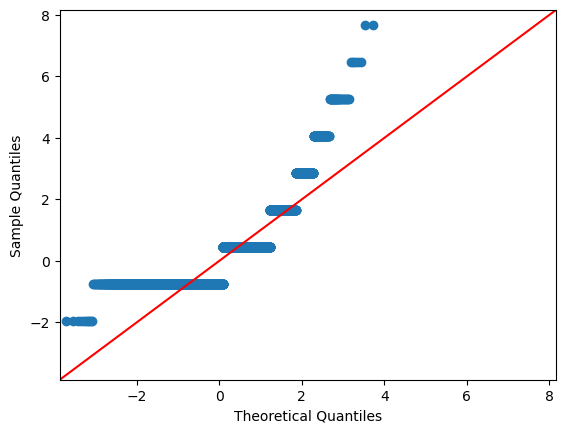

In [251]:
sm.qqplot(df3['bathrooms'].values, fit=True, line='45')
plt.show()

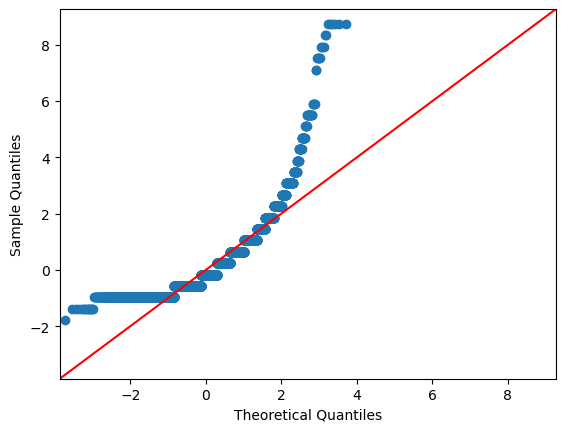

In [252]:
sm.qqplot(df3['floor'].values, fit=True, line='45')
plt.show()

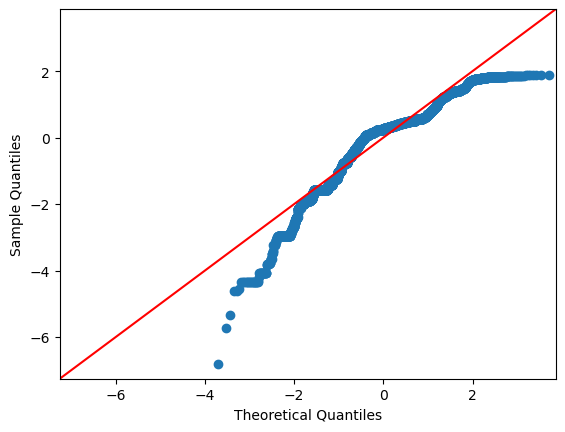

In [253]:
sm.qqplot(df3['year_built'].values, fit=True, line='45')
plt.show()

## Correlation plot

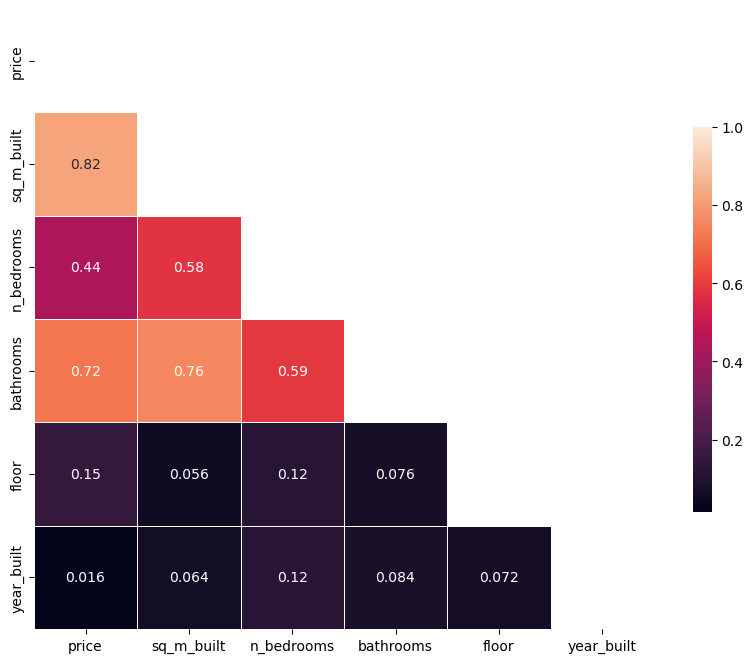

In [254]:
corr=np.abs(df_num.corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(10, 10))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

## Booleans to binary

In [255]:
df3.dtypes

property_type        object
neighborhood         object
city                 object
price               float64
sq_m_built            int64
n_bedrooms            int64
bathrooms             int64
floor                 int64
year_built          float64
exterior               bool
lift                   bool
terrace                bool
balcony                bool
second_hand            bool
needs_renovating       bool
parking                bool
swimming_pool          bool
garden                 bool
air_conditioning       bool
heating                bool
description          object
dtype: object

In [256]:
bool_columns = df3.select_dtypes(include='bool').columns

In [257]:
df3[bool_columns] = df3[bool_columns].astype(int)

In [258]:
df_num = df3.select_dtypes(include=['number'])

## Dealing with categorical columns

> Mean per city

In [259]:
city_avg_price = df3.groupby('city')['price'].mean()

In [260]:
min_price = city_avg_price.min()

In [261]:
city_price_diff = city_avg_price / min_price

In [262]:
df3['price_cheap_city'] = df3['city'].map(city_price_diff)

> Mean per neighborhood

In [263]:
neigh_avg_price = df3.groupby('neighborhood')['price'].mean()

In [264]:
min_price_neigh = neigh_avg_price.min()

In [265]:
neigh_price_diff = neigh_avg_price / min_price_neigh

In [266]:
df3['price_cheap_neigh'] = df3['neighborhood'].map(neigh_price_diff)

> Mean by property type

In [267]:
property_avg_price = df3.groupby('property_type')['price'].mean()

In [268]:
min_price_property = property_avg_price.min()

In [269]:
property_price_diff = property_avg_price / min_price_property

In [270]:
df3['price_cheap_property'] = df3['property_type'].map(property_price_diff)

# A/B Test with booleans columns

## Hypothesis|

In [271]:
## Hipothesis 

## H0 == H1 
## H0 != H1

> Exterior column

In [272]:
exterior_true = df3[df3['exterior'] == 1]['price']
exterior_false = df3[df3['exterior'] == 0]['price']

In [273]:
mean_false = exterior_false.mean()
mean_true = exterior_true.mean()

In [274]:
t_stat, p_value = ttest_ind(exterior_false.dropna(), exterior_true.dropna(), equal_var=False)

In [275]:
t_stat, p_value

(-9.100210186059856, 1.380528033453541e-19)

In [276]:
print(f"Diff: €{mean_true - mean_false:.2f}")

Diff: €96082.62


In [277]:
if p_value < 0.05:
    print("Reject H0.")
else:
    print("Not reject H0")

Reject H0.


<Axes: xlabel='price', ylabel='Count'>

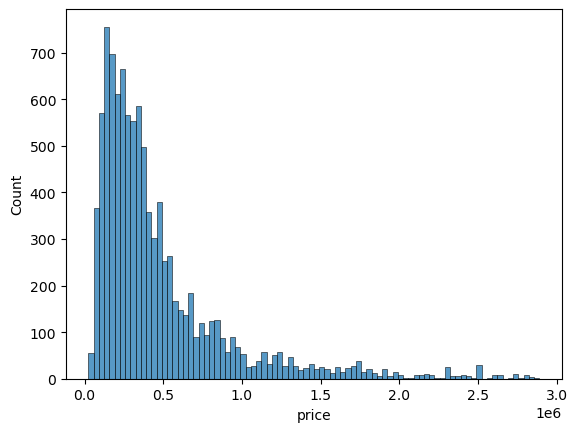

In [278]:
sns.histplot(data=df3, x= "price")

> Using log for price to see how are the values

<Axes: xlabel='price', ylabel='Count'>

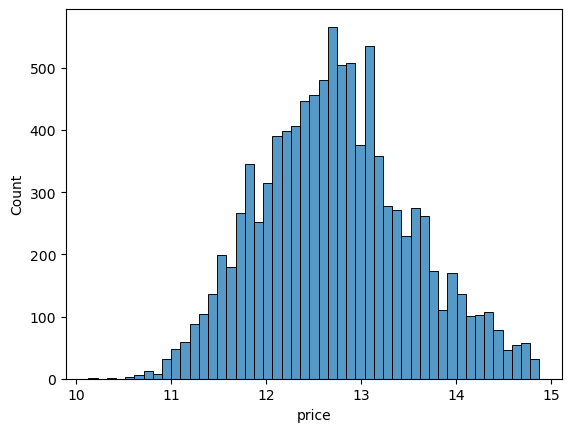

In [279]:
log_price = np.log(df3["price"])
sns.histplot(log_price)

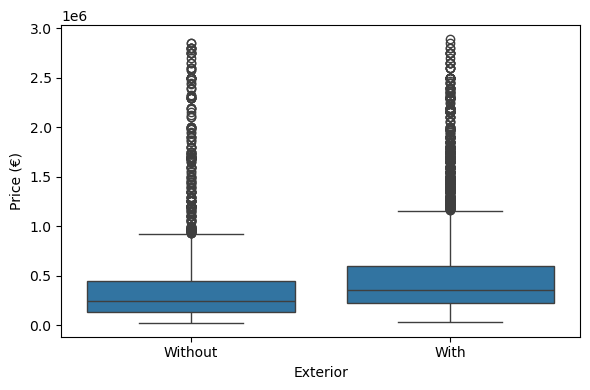

In [280]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='exterior', y='price', data=df3)
plt.xlabel('Exterior')
plt.ylabel('Price (€)')
plt.xticks([0, 1], ['Without', 'With'])
plt.tight_layout()
plt.show()

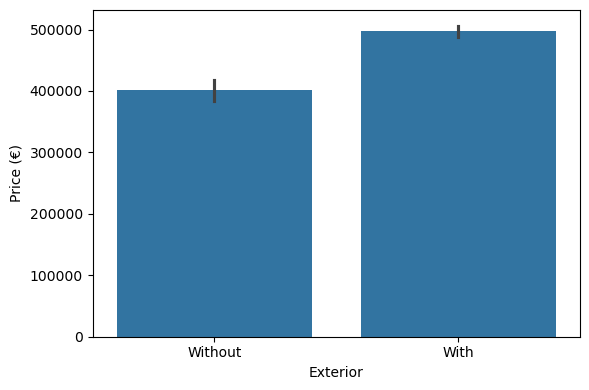

In [281]:
plt.figure(figsize=(6, 4))
sns.barplot(x='exterior', y='price', data=df3)
plt.xlabel('Exterior')
plt.ylabel('Price (€)')
plt.xticks([0, 1], ['Without', 'With'])
plt.tight_layout()
plt.show()

> Lift column

In [282]:
lift_true = df3[df3['lift'] == 1]['price']
lift_false = df3[df3['lift'] == 0]['price']

In [283]:
t_stat, p_value_lift = ttest_ind(lift_false.dropna(), lift_true.dropna(), equal_var=False)

In [284]:
if p_value_lift < 0.05:
    print("Reject H0.")
else:
    print("Not reject H0")

Reject H0.


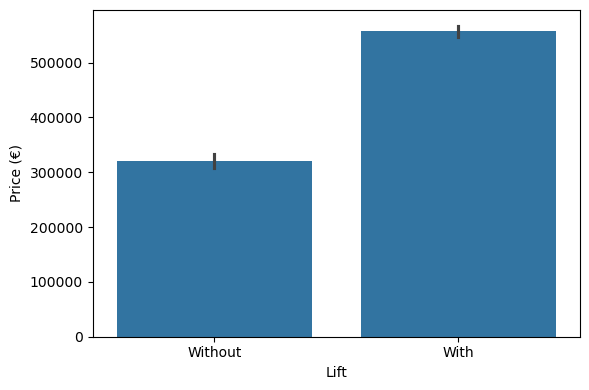

In [285]:
plt.figure(figsize=(6, 4))
sns.barplot(x='lift', y='price', data=df3)
plt.xlabel('Lift')
plt.ylabel('Price (€)')
plt.xticks([0, 1], ['Without', 'With'])
plt.tight_layout()
plt.show()

> terrace column

In [286]:
terrace_true = df3[df3['terrace'] == 1]['price']
terrace_false = df3[df3['terrace'] == 0]['price']

In [287]:
t_stat, p_value_terrace = ttest_ind(terrace_false.dropna(), terrace_true.dropna(), equal_var=False)

In [288]:
if p_value_terrace < 0.05:
    print("Reject H0.")
else:
    print("Not reject H0")

Reject H0.


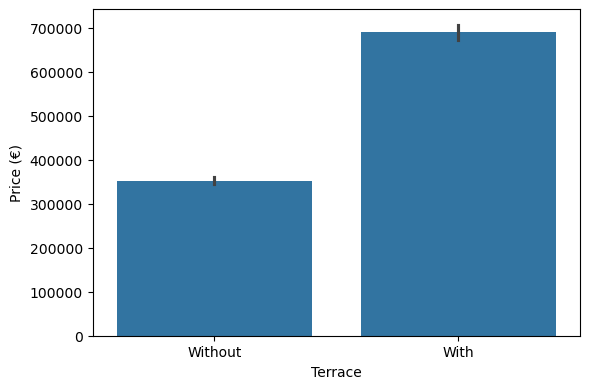

In [289]:
plt.figure(figsize=(6, 4))
sns.barplot(x='terrace', y='price', data=df3)
plt.xlabel('Terrace')
plt.ylabel('Price (€)')
plt.xticks([0, 1], ['Without', 'With'])
plt.tight_layout()
plt.show()

> Balcony column

In [290]:
balcony_true = df3[df3['balcony'] == 1]['price']
balcony_false = df3[df3['balcony'] == 0]['price']

In [291]:
t_stat, p_value_balcony = ttest_ind(balcony_false.dropna(), balcony_true.dropna(), equal_var=False)

In [292]:
if p_value_balcony < 0.05:
    print("Reject H0.")
else:
    print("Not reject H0")

Reject H0.


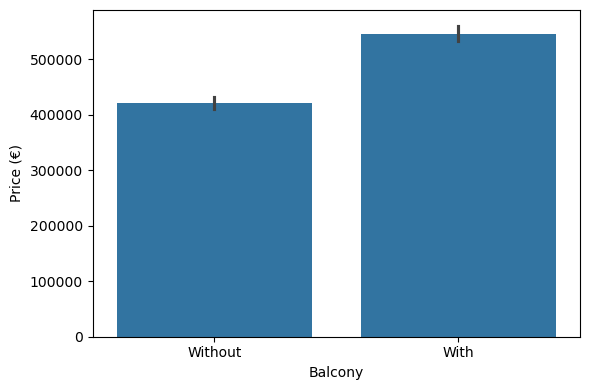

In [293]:
plt.figure(figsize=(6, 4))
sns.barplot(x='balcony', y='price', data=df3)
plt.xlabel('Balcony')
plt.ylabel('Price (€)')
plt.xticks([0, 1], ['Without', 'With'])
plt.tight_layout()
plt.show()

> Function for bool columns for AB test

In [294]:
def ab_test_binary_col(df, bool_column, target_col='price'):

    group_false = df[df[bool_column] == 0]['price']
    group_true = df[df[bool_column] == 1]['price']

    t_stat, p_value = ttest_ind(group_false.dropna(), group_true.dropna(), equal_var=False)


    if p_value_balcony < 0.05:
        print("Reject H0.")
    else:
        print("Not reject H0")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=bool_column, y=target_col, data=df)
    plt.title(f'{target_col.title()} por {bool_column}')
    plt.xlabel(bool_column)
    plt.ylabel(f'{target_col.title()} (€)')
    plt.xticks([0, 1], ['Without', 'With'])
    plt.tight_layout()
    plt.show()


> Second hand column

Reject H0.


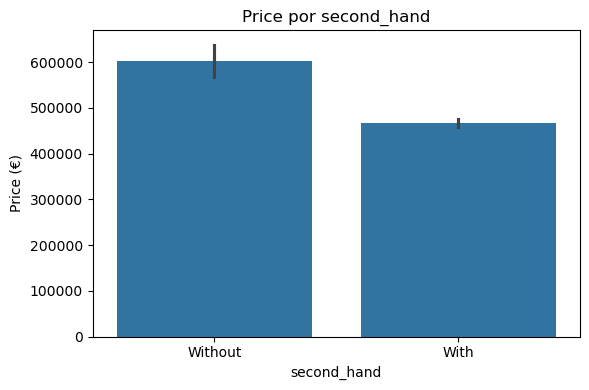

In [295]:
ab_test_binary_col(df3,'second_hand')

> Need renovation column

Reject H0.


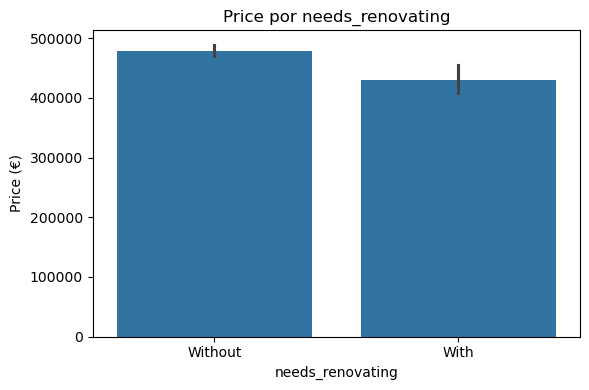

In [296]:
ab_test_binary_col(df3,'needs_renovating')

> Parking column 

Reject H0.


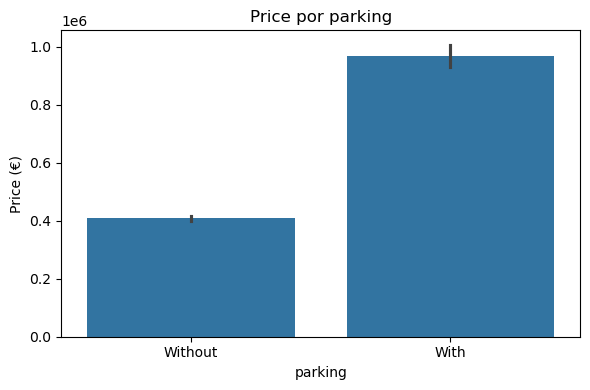

In [297]:
ab_test_binary_col(df3,'parking')

> Swimming pool column

Reject H0.


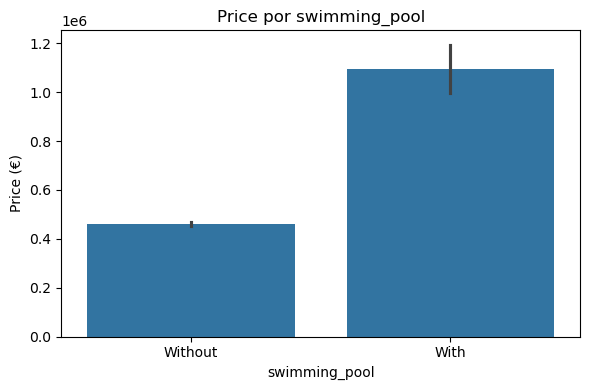

In [298]:
ab_test_binary_col(df3,'swimming_pool')

> Garden column

Reject H0.


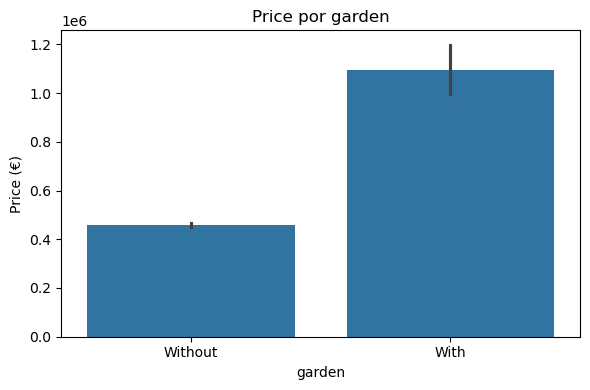

In [299]:
ab_test_binary_col(df3,'garden')

> Air column

Reject H0.


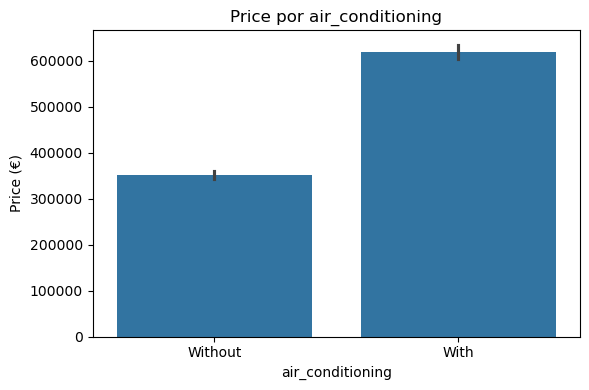

In [300]:
ab_test_binary_col(df3,'air_conditioning')

> Heating column

Reject H0.


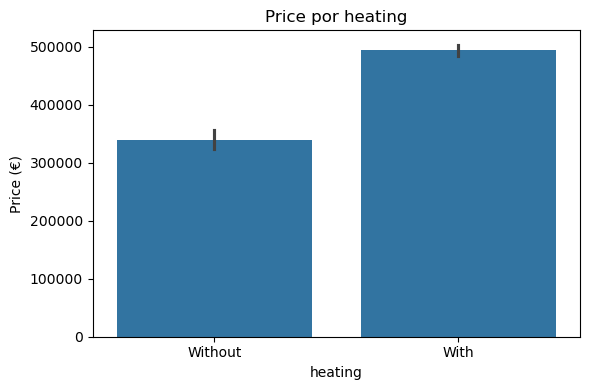

In [301]:
ab_test_binary_col(df3,'heating')

# Preparing data 

> Creating a logaritimic columns for the prices

In [302]:
df3 =df3[df3['price'] > 0]

In [303]:
df3['log_price'] = np.log(df3["price"])

> plot of corr from log price

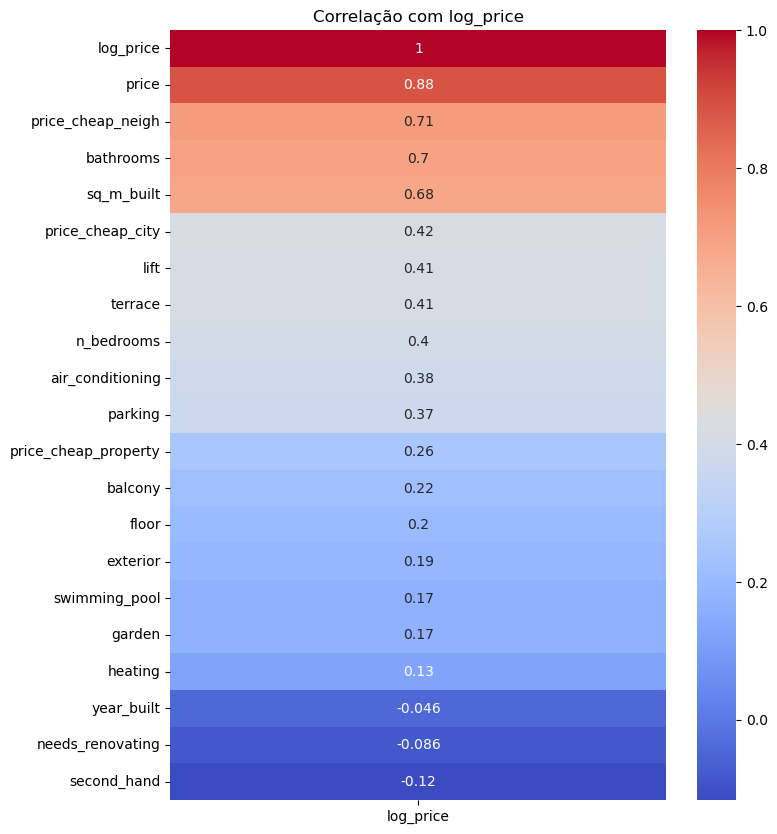

In [304]:
corr = df3.corr(numeric_only=True)
corr_target = corr['log_price'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm')
plt.title("Correlação com log_price")
plt.show()

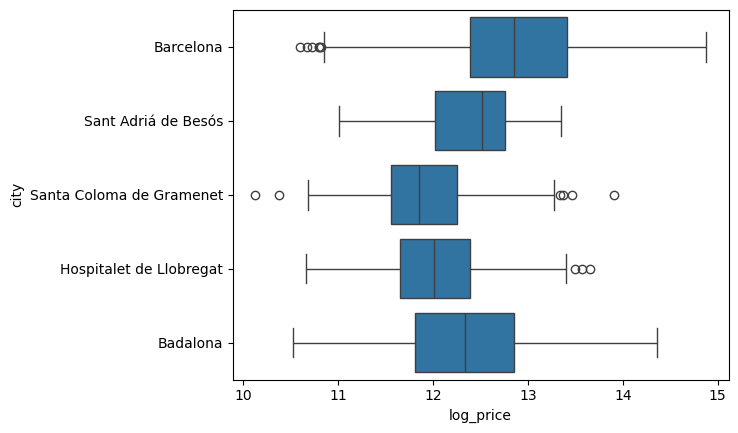

In [305]:
sns.boxplot(y = 'city', x = 'log_price', data = df3)
plt.show()

> Transforming city column

In [306]:
df3["city"].value_counts()

city
Barcelona                   7741
Badalona                     834
Hospitalet de Llobregat      814
Santa Coloma de Gramenet     501
Sant Adriá de Besós           74
Name: count, dtype: int64

In [307]:
df3['city'] = df3['city'].replace('Sant Adriá de Besós', 'Badalona')

> Transforming type column

In [308]:
df3['property_type'].unique()

array(['Flat / apartment', 'Studio flat', 'Penthouse', 'Duplex', 'House',
       'Semi-detached house', 'Terraced house', 'Detached house',
       'Village house', 'Estate', 'Tower'], dtype=object)

In [309]:
df3['property_type'].value_counts()

property_type
Flat / apartment       8215
Penthouse               692
Duplex                  443
Detached house          193
Studio flat             153
Terraced house          153
Semi-detached house      65
House                    45
Village house             2
Estate                    2
Tower                     1
Name: count, dtype: int64

In [310]:
df3['property_type'] = df3['property_type'].apply(lambda x: 'House' if ' house' in x.lower() else x)

In [311]:
df3['property_type'].value_counts()

property_type
Flat / apartment    8215
Penthouse            692
House                458
Duplex               443
Studio flat          153
Estate                 2
Tower                  1
Name: count, dtype: int64

> Droping tower and estate, quatity is not relevant

In [312]:
df3 = df3[~df3['property_type'].isin(['Estate','Tower'])]

In [313]:
df3[df3['property_type']== 'Flat / apartment'].groupby('n_bedrooms').size()

n_bedrooms
0        1
1      734
2     2176
3     3497
4     1357
5      339
6       82
7       22
8        3
9        3
14       1
dtype: int64

In [314]:
df3[df3['property_type']== 'Studio flat'].groupby('n_bedrooms').size()

n_bedrooms
0    153
dtype: int64

> Using replace, to unified Studio flat into flat / apart. 

In [315]:
df3['property_type'] = df3['property_type'].replace('Studio flat', 'Flat / apartment')

> Transforming neighborhood column

In [316]:
df3['neighborhood'].value_counts()

neighborhood
El Raval                  522
Ciutat Vella              367
El Gòtic                  341
La Dreta de l'Eixample    339
Les Corts                 283
                         ... 
Artigues                    3
Canyadó                     3
Granvia L-H                 3
Canyet                      2
Mas Ram                     2
Name: count, Length: 130, dtype: int64

> Eliminate neighborhood with low presence

In [317]:
neigh_counts = df3['neighborhood'].value_counts()
high_neigh = neigh_counts[neigh_counts>=30].index
df3['neighborhood'] = df3['neighborhood'].apply(lambda x: x if x in high_neigh else 'Other')

> For train test i'll not need description column.

In [318]:
df3 = df3.drop("description", axis=1)

# Saving the file 

In [319]:
df3.head()

,property_type,neighborhood,city,price,sq_m_built,n_bedrooms,bathrooms,floor,year_built,exterior,...,needs_renovating,parking,swimming_pool,garden,air_conditioning,heating,price_cheap_city,price_cheap_neigh,price_cheap_property,log_price
0,Flat / apartment,El Raval,Barcelona,530000.0,80,2,1,3,1912.0,1,...,0,0,0,0,1,1,3.086356,3.060900,2.030635,13.180632
1,Flat / apartment,El Raval,Barcelona,165000.0,58,2,1,3,1850.0,1,...,0,0,0,0,0,0,3.086356,3.060900,2.030635,12.013701
2,Flat / apartment,Ciutat Vella,Barcelona,430000.0,155,3,2,1,2003.0,1,...,0,0,0,0,1,1,3.086356,5.078603,2.030635,12.971540
3,Flat / apartment,El Raval,Barcelona,279999.0,89,2,2,3,1920.0,1,...,0,0,0,0,1,1,3.086356,3.060900,2.030635,12.542541
4,Flat / apartment,El Raval,Barcelona,230000.0,70,2,2,1,1900.0,1,...,0,0,0,0,1,0,3.086356,3.060900,2.030635,12.345835


In [320]:
df3.to_csv(r'..\data\clean\df_clean.csv', index=False)

## Train Test Split

In [148]:
features = df3.drop(columns = ['price','second_hand','heating','needs_renovating','log_price'])
target = df3["log_price"]

In [149]:
X_train, X_test, y_train, y_test = train_test_split(features,target, test_size = 0.20, random_state=0)

In [150]:
print("X_train shape:", X_train.shape)
print("X_train columns:", X_train.columns)
print("X_test shape:", X_test.shape)
print("X_test columns:", X_test.columns)

X_train shape: (7968, 19)
X_train columns: Index(['property_type', 'neighborhood', 'city', 'sq_m_built', 'n_bedrooms',
       'bathrooms', 'floor', 'year_built', 'exterior', 'lift', 'terrace',
       'balcony', 'parking', 'swimming_pool', 'garden', 'air_conditioning',
       'price_cheap_city', 'price_cheap_neigh', 'price_cheap_property'],
      dtype='object')
X_test shape: (1993, 19)
X_test columns: Index(['property_type', 'neighborhood', 'city', 'sq_m_built', 'n_bedrooms',
       'bathrooms', 'floor', 'year_built', 'exterior', 'lift', 'terrace',
       'balcony', 'parking', 'swimming_pool', 'garden', 'air_conditioning',
       'price_cheap_city', 'price_cheap_neigh', 'price_cheap_property'],
      dtype='object')


In [151]:
numerical_col = ['sq_m_built','n_bedrooms','bathrooms','floor','year_built']

In [152]:
categorical_col = ['property_type','neighborhood','city']

In [153]:
bool_col_1 = ['exterior', 'lift', 'terrace', 'balcony', 'second_hand',
                  'needs_renovating', 'parking', 'swimming_pool', 'garden',
                  'air_conditioning', 'heating']

In [154]:
df3[bool_col_1].mean().sort_values()

swimming_pool       0.021584
garden              0.021584
parking             0.115751
needs_renovating    0.130107
terrace             0.358097
balcony             0.410903
air_conditioning    0.451862
lift                0.644815
exterior            0.749222
heating             0.862564
second_hand         0.953720
dtype: float64

> Droping the featurings that have less importance

In [155]:
bool_col = ['exterior', 'lift', 'terrace', 'balcony', 'parking', 'swimming_pool', 'garden', 
                  'air_conditioning']

> Creating a pipeline to transform numerical col with power transf. and categorical with onehotenconding.

In [156]:
num_pipeline = Pipeline([('power', PowerTransformer())])

In [157]:
cat_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

In [158]:
bool_pipeline = 'passthrough'

In [159]:
from sklearn.compose import ColumnTransformer

In [160]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline,numerical_col),
    ('cat',cat_pipeline,categorical_col),
    ('bool',bool_pipeline,bool_col)], remainder='drop')
    

In [161]:
model = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', BaggingRegressor(random_state=0))])

In [162]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor', BaggingRegressor(random_state=0))])

In [163]:
y_pred_log = model.predict(X_test)

In [164]:
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

In [165]:
print(f"MAE: {mean_absolute_error(y_true, y_pred):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):,.2f} €")
print(f"R2: {r2_score(y_true, y_pred):.2f}")

MAE: 97,067.44 €
RMSE: 184,369.09 €
R2: 0.82


> Using Gradient Boosting 

In [166]:
model_gradient = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=0))])

In [167]:
model_gradient.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor', GradientBoostingRegressor(random_state=0))])

In [168]:
y_pred_log_gra = model_gradient.predict(X_test)

In [169]:
y_pred_gra = np.exp(y_pred_log_gra)
y_true_gra = np.exp(y_test)

In [170]:
print(f"MAE: {mean_absolute_error(y_true_gra, y_pred_gra):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_gra, y_pred_gra)):,.2f} €")
print(f"R2: {r2_score(y_true_gra, y_pred_gra):.2f}")

MAE: 110,592.42 €
RMSE: 197,135.32 €
R2: 0.80


> Using Random Forest 

In [171]:
model_rforest = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor',RandomForestRegressor(n_estimators=100, max_depth=20, random_state=0))])

In [172]:
model_rforest.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, random_state=0))])

In [173]:
y_pred_log_rforest = model_rforest.predict(X_test)

In [174]:
y_pred_rforest = np.exp(y_pred_log_rforest)
y_true_rforest = np.exp(y_test)

In [175]:
print(f"MAE: {mean_absolute_error(y_true_rforest, y_pred_rforest):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_rforest, y_pred_rforest)):,.2f} €")
print(f"R2: {r2_score(y_true_rforest, y_pred_rforest):.2f}")
mape = mean_absolute_percentage_error(y_true_rforest, y_pred_rforest)
print("MAPE: {:.2f}%".format(mape*100))

MAE: 93,387.43 €
RMSE: 177,555.33 €
R2: 0.84
MAPE: 20.66%


> Using Adaboost

In [176]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

In [177]:
model_adaboost = AdaBoostRegressor(DecisionTreeRegressor(max_depth=10), 
                                   n_estimators=100, learning_rate=0.3)

In [178]:
model_adaboost = Pipeline([
    ('preprocessing',preprocessor),
    ('regressor', AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100,learning_rate=0.1,random_state=0))])

In [179]:
model_adaboost.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['sq_m_built', 'n_bedrooms',
                                                   'bathrooms', 'floor',
                                                   'year_built']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['property_type',
                                                   'neighborhood', 'city']),
                                                 ('bool', 'passthrough',
                                                  ['exterior', 'lift',
                                                   'terrace', 'balcony',
                                                   'parking', 'swimming_pool',
                                                   'garden',
                                                   'air_conditioning'])])),
                ('regressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=20),
                                   learning_rate=0.1, n_estimators=100,
                                   random_state=0))])

In [180]:
y_pred_log_adaboost = model_adaboost.predict(X_test)

In [181]:
y_pred_adaboost = np.exp(y_pred_log_adaboost)
y_true_adaboost = np.exp(y_test)

In [182]:
print(f"MAE: {mean_absolute_error(y_true_adaboost, y_pred_adaboost):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_adaboost, y_pred_adaboost)):,.2f} €")
print(f"R2: {r2_score(y_true_adaboost, y_pred_adaboost):.2f}")
mape = mean_absolute_percentage_error(y_true_adaboost, y_pred_adaboost)
print("MAPE: {:.2f}%".format(mape*100))

MAE: 87,383.24 €
RMSE: 182,119.24 €
R2: 0.83
MAPE: 19.38%


In [183]:
joblib.dump(model_adaboost, r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\models\model_ada.pkl")

['C:\\Users\\User\\Desktop\\IronHack\\Week_8\\Day1\\final_project\\models\\model_ada.pkl']

> Scatter plot of estimate value and real 

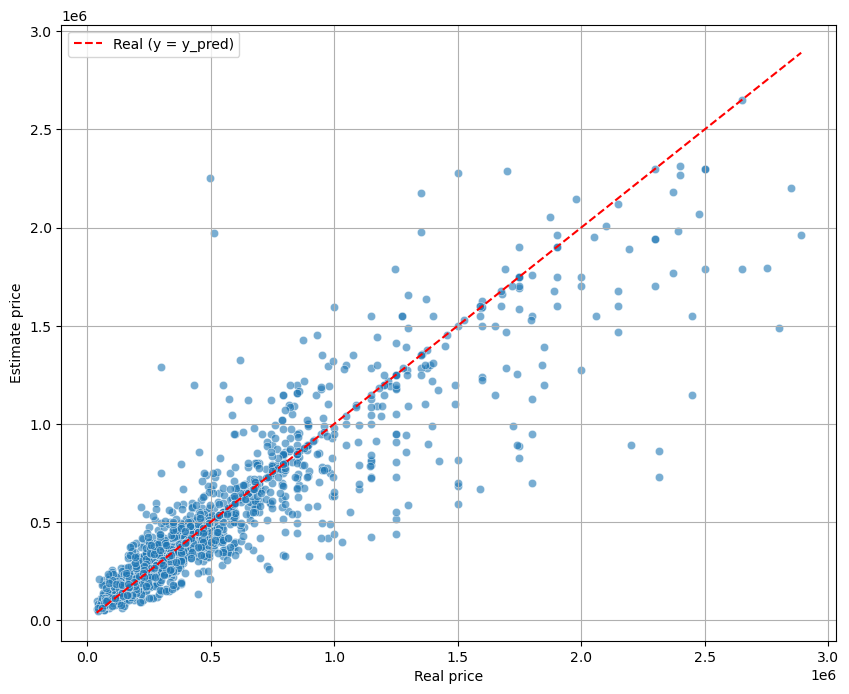

In [184]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_true_adaboost, y=y_pred_adaboost, alpha=0.6)
plt.plot([y_true_adaboost.min(), y_true_adaboost.max()],
         [y_true_adaboost.min(), y_true_adaboost.max()],
         '--', color='red', label='Real (y = y_pred)')
plt.xlabel('Real price')
plt.ylabel('Estimate price')
plt.legend()
plt.grid(True)
plt.show()

In [185]:
model_adaboost_gs = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=0),
        random_state=0))])


In [186]:
parameter_grid = {
    'regressor__n_estimators': [100],
    'regressor__learning_rate': [0.1, 0.3],
    'regressor__estimator__max_depth': [5, 10]}

confidence_level = 0.95 
folds = 10


gs = GridSearchCV(model_adaboost_gs, param_grid=parameter_grid, cv=folds, verbose=10)

start_time = time.time()
gs.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {gs.best_params_}")
print(f"The R2 is: {gs.best_score_: .4f}")

results_gs_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)

gs_mean_score = results_gs_df.iloc[0,-3]
gs_sem = results_gs_df.iloc[0,-2] / np.sqrt(folds)

gs_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
gs_lower_bound = gs_mean_score - ( gs_tc * gs_sem )
gs_upper_bound = gs_mean_score + ( gs_tc * gs_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: ({gs_lower_bound: .4f}, {gs_mean_score: .4f}, {gs_upper_bound: .4f})")

best_model_gs = gs.best_estimator_

y_pred_train_df = best_model_gs.predict(X_train)
y_pred_test_df  = np.exp(best_model_gs.predict(X_test))
y_true_test = np.exp(y_test)

print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df,y_true_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_true_test, y_pred_test_df): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_true_test, y_pred_test_df): .2f}")
print(f"Test R2 score:  {r2_score(y_test, best_model_gs.predict(X_test)):.4f}")
print(f"R²: {r2_score(y_true_test, y_pred_test_df):.4f}")
mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test_df)
print(f"Test MAPE: {mape_test*100:.2f}%")
print("\n")

Fitting 10 folds for each of 4 candidates, totalling 40 fits
[CV 1/10; 1/4] START regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100
[CV 1/10; 1/4] END regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100;, score=0.800 total time=   8.8s
[CV 2/10; 1/4] START regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100
[CV 2/10; 1/4] END regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100;, score=0.812 total time=   9.4s
[CV 3/10; 1/4] START regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100
[CV 3/10; 1/4] END regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100;, score=0.813 total time=   5.5s
[CV 4/10; 1/4] START regressor__estimator__max_depth=5, regressor__learning_rate=0.1, regressor__n_estimators=100
[CV 4/10; 1/4] END regressor__estimator__max_dep


KeyboardInterrupt



In [ ]:
model_hgb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', HistGradientBoostingRegressor())
])

In [ ]:
parameter_grid = {
    'regressor__max_iter': [100],
    'regressor__max_depth': [5, 10]}

confidence_level = 0.95 
folds = 10


gs = GridSearchCV(model_hgb, param_grid=parameter_grid, cv=folds, verbose=10)

start_time = time.time()
gs.fit(X_train, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {gs.best_params_}")
print(f"The R2 is: {gs.best_score_: .4f}")

results_hgb_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)

hgb_mean_score = results_hgb_df.iloc[0,-3]
hgb_sem = results_hgb_df.iloc[0,-2] / np.sqrt(folds)

hgb_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
hgb_lower_bound = hgb_mean_score - ( hgb_tc * hgb_sem )
hgb_upper_bound = hgb_mean_score + ( hgb_tc * hgb_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: ({hgb_lower_bound: .4f}, {hgb_mean_score: .4f}, {hgb_upper_bound: .4f})")

best_model_hgb = gs.best_estimator_

y_pred_train_df = best_model_hgb.predict(X_train)
y_pred_test_df  = np.exp(best_model_hgb.predict(X_test))
y_true_test = np.exp(y_test)

print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df,y_true_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_true_test, y_pred_test_df): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_true_test, y_pred_test_df): .2f}")
print(f"Test R2 score:  {r2_score(y_test, best_model_hgb.predict(X_test)):.4f}")
print(f"R²: {r2_score(y_true_test, y_pred_test_df):.4f}")
mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test_df)
print(f"Test MAPE: {mape_test*100:.2f}%")
print("\n")

In [ ]:
residuals = y_true_test - y_pred_test_df
sns.scatterplot(x=y_true_test, y=residuals, alpha=0.6)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('True Price')
plt.ylabel('Residual (True - Predicted)')
plt.title('Resíduos do modelo')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
import joblib

model_hgb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', HistGradientBoostingRegressor())
])

params = {
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_iter': [100, 200]
}

gs = GridSearchCV(model_hgb, param_grid=params, cv=3)
gs.fit(X_train, y_train)

joblib.dump(gs.best_estimator_, r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\models\model_hgb.pkl")


## Random Forest 

In [ ]:
model_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [ ]:
from scipy.stats import randint
param_dist = {
    'regressor__n_estimators': randint(100, 300),
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}
folds = 10
confidence_level = 0.95
search = RandomizedSearchCV(
    model_rf,
    param_distributions=param_dist,
    n_iter=20,  # bem mais leve que o grid
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
search.fit(X_train, y_train_log)
end_time = time.time()

print(f"\nTempo de busca: {end_time - start_time:.2f} segundos")
print(f"Melhores hiperparâmetros: {search.best_params_}")
print(f"Melhor R² (validação cruzada): {search.best_score_:.4f}")

results_df = pd.DataFrame(search.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0, -3]
sem = results_df.iloc[0, -2] / np.sqrt(folds)
t_crit = st.t.ppf(1 - (1 - confidence_level) / 2, df=folds - 1)
ci_lower = mean_score - (t_crit * sem)
ci_upper = mean_score + (t_crit * sem)
print(f"Intervalo de confiança do R²: ({ci_lower:.4f}, {mean_score:.4f}, {ci_upper:.4f})")

best_rf_model = search.best_estimator_
y_pred_log = best_rf_model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

print(f"MAE: {mean_absolute_error(y_true, y_pred):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):,.2f} €")
print(f"R2: {r2_score(y_true, y_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_true, y_pred)*100:.2f}%")

## LGBMRegrassor

In [187]:
from lightgbm import LGBMRegressor

In [188]:
model_lgb = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=1000, learning_rate=0.05))
])

model_lgb.fit(X_train, y_train)
y_pred_log = model_lgb.predict(X_test)
y_pred = np.exp(y_pred_log)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 739
[LightGBM] [Info] Number of data points in the train set: 7968, number of used features: 108
[LightGBM] [Info] Start training from score 12.732529


In [189]:
y_true = np.exp(y_test)

print(f"MAE: {mean_absolute_error(y_true, y_pred):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):,.2f} €")
print(f"R2: {r2_score(y_true, y_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_true, y_pred)*100:.2f}%")

MAE: 87,357.19 €
RMSE: 163,293.05 €
R2: 0.86
MAPE: 18.80%


In [190]:
test_row = X_test.iloc[[0]].copy()
test_row["n_bedrooms"] = 1
pred1 = np.exp(model.predict(test_row))

test_row["n_bedrooms"] = 2
pred2 = np.exp(model.predict(test_row))

print(pred1, pred2, pred2 - pred1)

[351012.91927091] [351012.91927091] [0.]


## Normalization

> StandardScaler

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled_np = scaler.transform(X_train)
X_test_scaled_np  = scaler.transform(X_test)

X_train_standarized = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
X_test_standarized  = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)

In [ ]:
with open(r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\scalers\scaler_novo.pkl","wb") as file:
    pickle.dump(scaler, file)

## KNN modeling 

In [ ]:
knn = KNeighborsRegressor(n_neighbors=10)

In [ ]:
knn.fit(X_train_standarized, y_train) # y_real_pred_train = np.exp(y_pred_train)

In [ ]:
print(f"The R2 of the model on the TEST set is: {knn.score(X_test_standarized, y_test): .2f}")

> ajust test back for real 

In [ ]:
from sklearn.pipeline import Pipeline
model = Pipeline(steps=[('preprocessor', StandardScaler()),('regressor', KNeighborsRegressor(n_neighbors=10))])

In [ ]:
model.fit(X_train_standarized,y_train)

In [ ]:
with open(r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\pipelines\sdtscaler_knn.pkl", "wb") as file:
    pickle.dump(model, file)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

In [ ]:
print(f"MAE: €{mae:.2f}, R²: {r2:.2f}")

> MinMaxscaler

In [ ]:
normalizer = MinMaxScaler()

In [ ]:
normalizer.fit(X_train)

In [ ]:
with open("../scalers/minmax_scaler.pkl", "wb") as file:
    pickle.dump(normalizer, file)

In [ ]:
X_train_norm = normalizer.transform(X_train)

X_test_norm = normalizer.transform(X_test)

In [ ]:
X_train_norm_df = pd.DataFrame(X_train_norm, columns=X_train.columns, index=X_train.index )

In [ ]:
X_test_norm_df = pd.DataFrame(X_test_norm, columns=X_test.columns, index=X_test.index)

In [ ]:
print("X_train shape:", X_train_norm_df.shape)
print("X_train columns:", X_train_norm_df.columns)
print("X_test shape:", X_test_norm_df.shape)
print("X_test columns:", X_test_norm_df.columns)

> KNN Regressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=10)

In [ ]:
knn.fit(X_train_norm_df, y_train)

In [ ]:
print(f"The R2 of the model on the TEST set is: {knn.score(X_test_norm_df, y_test): .2f}")

In [ ]:
knn.fit(X_train_standarized, y_train)

In [ ]:
print(f"The R2 of the model on the TEST set is: {knn.score(X_test_standarized, y_test): .2f}")

## LinearRegression

In [ ]:
lin_reg = LinearRegression()

In [ ]:
lin_reg2 = LinearRegression()

In [ ]:
lin_reg.fit(X_train_norm_df, y_train)

In [ ]:
lin_reg2.fit(X_train_standarized, y_train)

In [ ]:
y_pred_test = model.predict(X_test)
y_pred = np.exp(y_pred_test)
y_true = np.exp(y_test)

In [ ]:
y_pred_test = lin_reg.predict(X_test_norm_df)

#lin_reg.score(X_test_norm_df, y_test)

print(f"MAE {mean_absolute_error(y_true, y_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"MSE {mean_squared_error(y_true, y_test): .2f}") # mean(error**2) = mean((y_test - y_pred_test)**2)
print(f"RMSE, {root_mean_squared_error(y_true, y_test): .2f}") # sqrt( mean( (y_test - y_pred_test)^2 ) ) # b0, b1, b2...
print(f"R2 score, {lin_reg.score(X_test_norm_df, y_test): .2f}") # r2_score

In [ ]:
sns.scatterplot(x=y_true, y=y_pred_test);

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
y_pred_log2 = lin_reg2.predict(X_test_standarized)
y_pred = np.exp(y_pred_log2)
y_true = np.exp(y_test)

In [ ]:
print(f"MAE {mean_absolute_error(y_true, y_pred): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"MSE {mean_squared_error(y_true, y_pred): .2f}")
print(f"RMSE, {root_mean_squared_error(y_true, y_pred): .2f}") # sqrt( mean( (y_test - y_pred_test)^2 ) ) # b0, b1, b2...
print(f"R2 score, {r2_score(y_true, y_pred): .2f}")

In [ ]:
sns.scatterplot(x=y_test, y=y_pred_log2);

> Coef. from stand and norm df:

In [ ]:
model_std = LinearRegression().fit(X_train_standarized, y_train)
model_norm = LinearRegression().fit(X_train_norm, y_train)

print("Standard Coefs:", model_std.coef_)
print("Normalized Coefs:", model_norm.coef_)

> Plot of how much impact each coef. on price.

In [ ]:
import matplotlib.pyplot as plt

coefs = pd.Series(model_std.coef_, index=X_train.columns)
coefs.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Impact of variables on price")
plt.show()

## Decision Tree

In [ ]:
tree = DecisionTreeRegressor(max_depth=10)

In [ ]:
tree.fit(X_train_standarized, y_train)

In [ ]:
y_pred_test_dt = tree.predict(X_test_standarized)

print(f"MAE, {mean_absolute_error(y_pred_test_dt, y_test): .2f}")
print(f"MSE, {mean_squared_error(y_pred_test_dt, y_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test_dt, y_test): .2f}")
print(f"R2 score, {tree.score(X_test_standarized, y_test): .2f}")

In [ ]:
tree_importance = {feature : importance for feature, importance in zip(X_train_norm_df.columns, tree.feature_importances_)}
tree_importance

In [ ]:
coefs = pd.Series(tree_importance, index=X_train.columns)
coefs.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Impact of variables on price")
plt.show()

# Ensemble

## Bagging and Pasting

In [ ]:
bagging_reg = BaggingRegressor(DecisionTreeRegressor(max_depth=20),
                               n_estimators=100, # number of models to use
                               max_samples = 1000)

In [ ]:
bagging_reg.fit(X_train, y_train)

In [ ]:
y_pred_test_bagging = bagging_reg.predict(X_test)

In [ ]:
y_pred_bagging = np.exp(y_pred_test_bagging)
y_true_bagging = np.exp(y_test)

In [ ]:
print(f"MAE {mean_absolute_error(y_true_bagging, y_pred_bagging): .2f}")
print(f"MSE {mean_squared_error(y_true_bagging, y_pred_bagging): .2f}")
print(f"RMSE {root_mean_squared_error(y_true_bagging, y_pred_bagging): .2f}")
print(f"R2 score {bagging_reg.score(X_test, y_test): .2f}")
print(r2_score(y_true_bagging, y_pred_bagging))

In [ ]:
with open(r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\models\model_bagging.pkl", "wb") as file:
    pickle.dump(bagging_reg, file)

## AdaBoost

In [ ]:
ada_reg = AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100)

In [ ]:
ada_reg.fit(X_train_standarized, y_train)

In [ ]:
y_pred_test_ada = ada_reg.predict(X_test_standarized)

In [ ]:
y_pred = np.exp(y_pred_test_ada)
y_true = np.exp(y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print(f"MAE, {mean_absolute_error(y_true,y_pred): .2f}")
print(f"MSE, {mean_squared_error(y_true, y_pred): .2f}")
print(f"RMSE, {np.sqrt(mean_squared_error(y_true, y_pred)): .2f}")
print(f"R2 score, {r2_score(y_true, y_pred): .2f}")

In [ ]:
print("y_pred[:5]:", y_pred[:5])
print("y_true[:5]:", y_true[:5])
print("Diffs:", y_pred[:5] - y_true[:5])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ada_reg, X_train_standarized, y_train, cv=5, scoring='r2')
print("Cross-val R2:", scores)
print("Mean CV R2:", scores.mean())

In [ ]:
print(X_train.columns.tolist())

In [ ]:
print(X_test_standarized.shape)
print(X_train_standarized.shape)

In [ ]:
ada_reg = AdaBoostRegressor(DecisionTreeRegressor(max_depth=3),
                            n_estimators=20)

In [ ]:
ada_reg.fit(X_train_standarized, y_train)

In [ ]:
y_pred_test_ada = ada_reg.predict(X_test_standarized)

In [ ]:
y_pred = np.exp(y_pred_test_ada)
y_true = np.exp(y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print(f"MAE, {mean_absolute_error(y_true,y_pred): .2f}")
print(f"MSE, {mean_squared_error(y_true, y_pred): .2f}")
print(f"RMSE, {np.sqrt(mean_squared_error(y_true, y_pred)): .2f}")
print(f"R2 score, {r2_score(y_true, y_pred): .2f}")

In [ ]:
with open(r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\models\best_model.pkl", "wb") as file:
    pickle.dump(ada_reg, file)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train) 
with open(r"C:\Users\User\Desktop\IronHack\Week_8\Day1\final_project\scalers\scaler_novo.pkl", "wb") as file:
    pickle.dump(scaler, file)

## Gradient Boosting

In [ ]:
gb_reg = GradientBoostingRegressor(max_depth=20,
                                   n_estimators=100)

In [ ]:
gb_reg.fit(X_train_standarized, y_train)

In [ ]:
y_pred_test_gb = gb_reg.predict(X_test_standarized)

print(f"MAE, {mean_absolute_error(y_pred_test_gb, y_test): .2f}")
print(f"MSE, {mean_squared_error(y_pred_test_gb, y_test): .2f}")
print(f"RMSE, {root_mean_squared_error(y_pred_test_gb, y_test): .2f}")
print(f"R2 score, {gb_reg.score(X_test_standarized, y_test): .2f}")

# Hyperparameters

##  Grid Search

In [ ]:
parameter_grid = {"max_depth": [10, 50],
                  "min_samples_split": [4, 16],
                  "max_leaf_nodes": [250, 100],
                  "max_features": ["sqrt", "log2"]}

dt = DecisionTreeRegressor(random_state=123)

confidence_level = 0.95
folds = 10

gs = GridSearchCV(dt, param_grid=parameter_grid, cv=folds, verbose=10) 

start_time = time.time()
gs.fit(X_train_standarized, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {gs.best_params_}")
print(f"The R2 is: {gs.best_score_: .4f}")

results_gs_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)

gs_mean_score = results_gs_df.iloc[0,-3]
gs_sem = results_gs_df.iloc[0,-2] / np.sqrt(folds)

gs_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
gs_lower_bound = gs_mean_score - ( gs_tc * gs_sem )
gs_upper_bound = gs_mean_score + ( gs_tc * gs_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: \({gs_lower_bound: .4f}, {gs_mean_score: .4f}, {gs_upper_bound: .4f}) ")

best_model = gs.best_estimator_

y_pred_train_df = best_model.predict(X_train_standarized)
y_pred_test_df  = best_model.predict(X_test_standarized)

print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df, y_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_pred_test_df, y_test): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_pred_test_df, y_test): .4f}")
print(f"Test R2 score:  {best_model.score(X_test_standarized, y_test): .4f}")
print("\n")

## Random Search

In [ ]:
parameter_grid = {"max_leaf_nodes": [int(x) for x in np.linspace(start = 5, stop = 30, num = 3)],
        "max_depth":[int(x) for x in np.linspace(1, 11, num = 3)]}

dt = DecisionTreeRegressor(random_state=123)

rs = RandomizedSearchCV(dt, param_distributions = parameter_grid, n_iter = 16, cv = folds, verbose=10, random_state=123)

start_time = time.time()
rs.fit(X_train_standarized, y_train)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")


print(f"The best combination of hyperparameters has been: {rs.best_params_}")
print(f"The R2 is: {rs.best_score_: .4f}")

results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)

#print(results_df.head())
rs_mean_score = results_rs_df.iloc[0,-3]
rs_sem = results_rs_df.iloc[0,-2] / np.sqrt(10)

rs_tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
rs_lower_bound = rs_mean_score - ( rs_tc * gs_sem )
rs_upper_bound = rs_mean_score + ( rs_tc * gs_sem )

print(f"The R2 confidence interval for the best combination of hyperparameters is: \
    ({rs_lower_bound: .4f}, {rs_mean_score: .4f}, {rs_upper_bound: .4f}) ")

#display(results_df)

# Let's store the best model
best_model = rs.best_estimator_

# Now is time evaluate the model in the test set
y_pred_test_df = best_model.predict(X_test_standarized)
y_pred_test_df = best_model.predict(X_test_standarized)


print("\n")
print(f"Test MAE: {mean_absolute_error(y_pred_test_df, y_test): .4f}")
print(f"Test MSE: {mean_squared_error(y_pred_test_df, y_test): .4f}")
print(f"Test RMSE: {root_mean_squared_error(y_pred_test_df, y_test): .4f}")
print(f"Test R2 score:  {best_model.score(X_test_standarized, y_test): .4f}")
print("\n")

## Bayesian search

In [ ]:
def objective(trial, confidence_level, folds):

    max_depth = trial.suggest_int("max_depth", 10, 50) 
    min_samples_split = trial.suggest_int("min_samples_split", 4, 16)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 250, 1000)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    dt = DecisionTreeRegressor(random_state=123,
                               max_depth=max_depth,
                               min_samples_split=min_samples_split,
                               max_leaf_nodes=max_leaf_nodes,
                               max_features=max_features)

    scores = cross_val_score(dt, X_train_standarized, y_train, cv=folds) 
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
    lower_bound = mean_score - ( tc * sem )
    upper_bound = mean_score + ( tc * sem )

    trial.set_user_attr("CV_score_summary", [round(lower_bound,4), round(np.mean(scores),4), round(upper_bound,4)])

    return np.mean(scores)


In [ ]:
confidence_level = 0.95
folds = 10

start_time = time.time()
study = optuna.create_study(direction="maximize") 
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")
print("The best combination of hyperparameters found was: ", study.best_params)
print(f"The best R2 found was: {study.best_value: .4f}")


In [ ]:
results = sorted([(index,
  trial.user_attrs['CV_score_summary'][0],
  trial.user_attrs['CV_score_summary'][1],
  trial.user_attrs['CV_score_summary'][2]) for index, trial in enumerate(study.trials)], key=lambda x: x[2], reverse=True)

print(f"The R2 confidence interval for the best combination of hyperparameters is: {results[0][1:]}")
